In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
class_count = {}
dataset_path = "../Rice Dataset/Original Dataset"
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        class_count[class_name] = len(os.listdir(class_path))
        print(f"Class: {class_name}, Count: {class_count[class_name]}") 

Class: Healthy, Count: 603
Class: Insect, Count: 281
Class: Leaf Scald, Count: 421
Class: Rice, Count: 16
Class: Rice Blast, Count: 696
Class: Rice Leaffolder, Count: 247
Class: Rice Stripes, Count: 266
Class: Rice Tungro, Count: 239


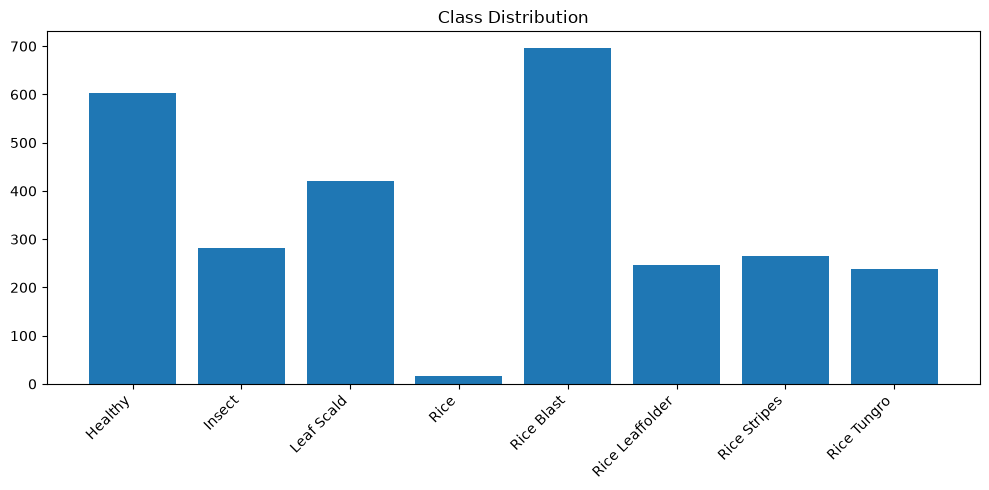

In [3]:
# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_count.keys(), class_count.values())
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

In [4]:
from torch.utils.data import Dataset
from PIL import Image

class RiceDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [5]:
print(os.listdir(dataset_path))

['Healthy', 'Insect', 'Leaf Scald', 'Rice', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro']


In [ ]:
def build_file_list(dataset_path):
    image_paths = []
    labels = []
    
    class_names = sorted([
        d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))
                         ])
    
    print("Classes found:")
    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for img in images:
            image_paths.append(os.path.join(class_path, img))
            labels.append(idx)
        
        print(f"  {idx}: {class_name} — {len(images)} images")
        
    return image_paths, labels, class_names
        

In [7]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.RandomVerticalFlip(p=0.3),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    ])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
from sklearn.model_selection import train_test_split

def split_dataset(labels, image_paths):
    train_paths, temp_paths, train_labels, temp_labels = train_test_split(
        image_paths, labels, test_size=0.3, stratify=labels, random_state=42
    )
    
    val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42)
    
    return train_paths, val_paths, test_paths, train_labels, val_labels, test_labels

In [9]:
from torch.utils.data import DataLoader

def create_dataloaders(train_paths, val_paths, test_paths, train_labels, val_labels, test_labels, batch_size=32):
    train_dataset = RiceDataset(train_paths, train_labels, transform=train_transforms)
    val_dataset = RiceDataset(val_paths, val_labels, transform=val_transform)
    test_dataset = RiceDataset(test_paths, test_labels, transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    
    return train_loader, val_loader, test_loader

In [10]:
def verify_dataloader(loader, class_names):
    # Get one batch
    images, labels = next(iter(loader))
    
    print(f"Batch image shape: {images.shape}")
    # Should be: torch.Size([32, 3, 224, 224])
    # [batch_size, channels, height, width]
    
    print(f"Batch label shape: {labels.shape}")
    # Should be: torch.Size([32])
    
    print(f"Image value range: "
          f"{images.min():.3f} to {images.max():.3f}")
    # Should be roughly -2 to 2 after normalization
    
    print(f"Labels in batch: "
          f"{[class_names[l] for l in labels[:5]]}")
    # Should show class names, not just numbers
    

In [11]:
import torch
import torch.nn as nn
from torchvision import models

def get_model(num_classes, pretrained=True):
    # Load MobileNetV3 Small — edge friendly
    model = models.mobilenet_v3_small(
        weights='IMAGENET1K_V1' if pretrained else None
    )

    # Replace the classifier head
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    return model

In [ ]:
import torch
from tqdm.notebook import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(tqdm(loader, desc="Training")):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


In [ ]:
def evaluate(model, loader, criterion, device, class_names):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(dim=1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    
    # Per class accuracy — important for imbalanced classes
    print("\nPer-class accuracy:")
    for class_idx, class_name in enumerate(class_names):
        class_mask = [l == class_idx for l in all_labels]
        class_preds = [
            all_predictions[i] for i, m 
            in enumerate(class_mask) if m
        ]
        class_true = [
            all_labels[i] for i, m 
            in enumerate(class_mask) if m
        ]
        if class_true:
            acc = sum(
                p == t for p, t 
                in zip(class_preds, class_true)
            ) / len(class_true)
            print(f"  {class_name}: {acc*100:.1f}%")
    
    return epoch_loss, epoch_acc

In [14]:
def train(config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    os.makedirs(config["output_dir"], exist_ok=True)
    
    image_paths, labels, class_names = build_file_list(
        config["dataset_path"]
    )
    
    split = split_dataset(labels, image_paths)
    loaders = create_dataloaders(*split, batch_size=config["batch_size"])
    train_loader, val_loader, test_loader = loaders
    
    verify_dataloader(train_loader, class_names)
    
    model = get_model(num_classes=len(class_names)).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    
    # Reduce LR when validation plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',      # maximize val accuracy
        patience=3,      # wait 3 epochs before reducing
        factor=0.5,      # halve the learning rate
    )
    
    # Training loop
    best_val_acc = 0.0
    history = []
    
    for epoch in range(config["epochs"]):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{config['epochs']}")
        print(f"{'='*50}")
        
        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader,
            criterion, optimizer, device
        )
        
        # Evaluate
        val_loss, val_acc = evaluate(
            model, val_loader,
            criterion, device, class_names
        )
        
        # Update scheduler
        scheduler.step(val_acc)
        
        # Print summary
        print(f"\nTrain — Loss: {train_loss:.4f} "
              f"Acc: {train_acc:.2f}%")
        print(f"Val   — Loss: {val_loss:.4f} "
              f"Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'class_names': class_names
            }, os.path.join(
                config["output_dir"], "best_model.pt"
            ))
            print(f"✓ Best model saved ({val_acc:.2f}%)")
        
        # Log history
        history.append({
            "epoch": epoch + 1,
            "train_loss": round(train_loss, 4),
            "train_acc": round(train_acc, 2),
            "val_loss": round(val_loss, 4),
            "val_acc": round(val_acc, 2)
        })
    
    print(f"\nTraining complete")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    
    return history, model, class_names
    

In [ ]:
config = {
    "dataset_path": "../Rice Dataset/Original Dataset",
    "output_dir": "./model_output",
    "batch_size": 32,
    "epochs": 20,
    "learning_rate": 1e-3
    }

train(config)

Using device: cpu
Classes found:
  7: Rice Tungro — 239 images


d:\project\bs_re\edge_applepietea\.venv-1\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
